# RMSE and Plot Generation:

In [24]:
def build_states_from_sim(pos, theta):
    """
    Convert simulator output into state vectors
    expected by the RMSE diagnostics.

    pos   : (T+1, N, 2)
    theta : (T+1, N)

    returns
    states : (T+1, 3N)
    """
    
    T_plus_1, N, _ = pos.shape
    
    states = np.zeros((T_plus_1, 3*N))
    
    states[:, 0::3] = pos[:,:,0]
    states[:, 1::3] = pos[:,:,1]
    states[:, 2::3] = theta
    
    return states

states = build_states_from_sim(pos, theta)

In [ ]:


def angle_diff(a, b):
    """
    Difference between two angles, wrapped to [-pi, pi).

    This avoids large artificial errors when angles are near the boundary,
    e.g. comparing +pi and -pi should give a small difference, not ~2pi.
    """
    return (a - b + np.pi) % (2 * np.pi) - np.pi


def periodic_error(a, b, L):
    """
    Difference between positions on a periodic box of size L.

    Returns the shortest displacement, so that errors
    across the boundary are treated correctly.
    """
    err = a - b
    err = err - L * np.round(err / L)
    return err


def compute_rmse_diagnostics(states, filt_means):
    """
    Compare the true states with EKF estimates over time.

    Computes root mean squared errors (RMSE) for:
    - x position
    - y position
    - combined position
    - heading

    Uses periodic differences for positions and wrapped differences for angles.
    """
    T_plus_1, state_dim = states.shape
    N = state_dim // 3  # number of agents

    # Store error at each time step
    pos_rmse_t = np.zeros(T_plus_1)
    heading_rmse_t = np.zeros(T_plus_1)
    x_rmse_t = np.zeros(T_plus_1)
    y_rmse_t = np.zeros(T_plus_1)

    for t in range(T_plus_1):
        # Extract true state
        x_true = states[t, 0::3]
        y_true = states[t, 1::3]
        th_true = states[t, 2::3]

        # Extract EKF estimate
        x_est = filt_means[t, 0::3]
        y_est = filt_means[t, 1::3]
        th_est = filt_means[t, 2::3]

        # Compute errors, respecting periodic geometry
        x_err = periodic_error(x_est, x_true, L)
        y_err = periodic_error(y_est, y_true, L)
        th_err = angle_diff(th_est, th_true)

        # RMSE across all agents at this time
        x_rmse_t[t] = np.sqrt(np.mean(x_err**2))
        y_rmse_t[t] = np.sqrt(np.mean(y_err**2))
        pos_rmse_t[t] = np.sqrt(np.mean(x_err**2 + y_err**2))
        heading_rmse_t[t] = np.sqrt(np.mean(th_err**2))

    # Collect full time series and summary statistics
    diagnostics = {
        "x_rmse_t": x_rmse_t,
        "y_rmse_t": y_rmse_t,
        "pos_rmse_t": pos_rmse_t,
        "heading_rmse_t": heading_rmse_t,
        "mean_x_rmse": np.mean(x_rmse_t),
        "mean_y_rmse": np.mean(y_rmse_t),
        "mean_pos_rmse": np.mean(pos_rmse_t),
        "mean_heading_rmse": np.mean(heading_rmse_t),
        "final_x_rmse": x_rmse_t[-1],
        "final_y_rmse": y_rmse_t[-1],
        "final_pos_rmse": pos_rmse_t[-1],
        "final_heading_rmse": heading_rmse_t[-1],
    }

    return diagnostics

In [ ]:
def unpack_state(z):
    # Convert the stacked state vector [x1,y1,th1, x2,y2,th2, ...]
    # back into positions and headings for each agent.
    N = len(z) // 3
    pos = np.zeros((N, 2))
    pos[:, 0] = z[0::3]
    pos[:, 1] = z[1::3]
    theta = wrap_angle(z[2::3])  # keep angles in [-pi, pi)
    return pos, theta


def build_dissertation_figure(
    pos,
    theta,
    filt_means,
    diagnostics,
    L,
    transition=300,
    snapshot_t=None,
    trail_len=40,
    arrow_scale=0.75,
    figsize=(15, 10),
    save_path=None
):
    """
    Build a summary figure showing how the EKF behaves over time and how well
    it reconstructs the flock at a given snapshot.
    """
    T_plus_1, N, _ = pos.shape

    # If no snapshot time is given, use the final time step
    if snapshot_t is None:
        snapshot_t = T_plus_1 - 1

    # Convert EKF state vectors into positions and headings
    pos_est = np.zeros_like(pos)
    theta_est = np.zeros_like(theta)
    for t in range(T_plus_1):
        p_est, th_est = unpack_state(filt_means[t])
        pos_est[t] = p_est
        theta_est[t] = th_est

    # Measure how aligned the system is over time (true vs EKF)
    psi_true = np.array([order_parameter(theta[t]) for t in range(T_plus_1)])
    psi_est = np.array([order_parameter(theta_est[t]) for t in range(T_plus_1)])

    # Set up figure layout (2x2 panels)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05], hspace=0.28, wspace=0.20)

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_order = fig.add_subplot(gs[0, 1])
    ax_true = fig.add_subplot(gs[1, 0])
    ax_ekf = fig.add_subplot(gs[1, 1])

    # Panel A: error over time
    tgrid = np.arange(T_plus_1)

    ax_rmse.plot(tgrid, diagnostics["pos_rmse_t"], label="Position RMSE", linewidth=2.2)
    ax_rmse.plot(tgrid, diagnostics["heading_rmse_t"], label="Heading RMSE", linewidth=2.0)

    # Mark where we consider the filter to have settled, and where the flocking transition occurs.
    ax_rmse.axvline(transition, linestyle="--", color="black", alpha=0.5, linewidth=1.2)

    ax_rmse.set_title("(A) EKF error over time", fontsize=13)
    ax_rmse.set_xlabel("Time step")
    ax_rmse.set_ylabel("RMSE")
    ax_rmse.grid(True, alpha=0.3)
    ax_rmse.legend(frameon=True)

    # Panel B: alignment (order parameter)
    ax_order.plot(tgrid, psi_true, label=r"True $\psi(t)$", linewidth=2.2)
    ax_order.plot(tgrid, psi_est, "--", label=r"EKF $\hat{\psi}(t)$", linewidth=2.0)

    ax_order.axvline(transition, linestyle="--", color="black", alpha=0.5, linewidth=1.2)

    ax_order.set_title("(B) Flocking order parameter", fontsize=13)
    ax_order.set_xlabel("Time step")
    ax_order.set_ylabel(r"$\psi(t)$")
    ax_order.set_ylim(-0.02, 1.02)
    ax_order.grid(True, alpha=0.3)
    ax_order.legend(frameon=True)

    # Prepare snapshot window (recent trajectory)
    start = max(0, snapshot_t - trail_len)

    # Use consistent colours for each agent
    cmap = plt.cm.get_cmap("tab20", N)
    colors = [cmap(i) for i in range(N)]

    # Set axes for spatial plots
    for ax in (ax_true, ax_ekf):
        ax.set_xlim(0, L)
        ax.set_ylim(0, L)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.25)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    ax_true.set_title(f"(C) True flock at t = {snapshot_t}", fontsize=13)
    ax_ekf.set_title(f"(D) EKF reconstruction at t = {snapshot_t}", fontsize=13)

    # Panel C: true system snapshot

    for i in range(N):
        # Plot recent trajectory for each agent
        xs = pos[start:snapshot_t + 1, i, 0]
        ys = pos[start:snapshot_t + 1, i, 1]
        xs_plot, ys_plot = break_periodic_trail(xs, ys, L)
        ax_true.plot(xs_plot, ys_plot, color=colors[i], linewidth=1.1, alpha=0.75)

    # Current positions
    ax_true.scatter(pos[snapshot_t, :, 0], pos[snapshot_t, :, 1], c=colors, s=22, zorder=3)

    # Heading directions
    u_true = arrow_scale * np.cos(theta[snapshot_t])
    v_true = arrow_scale * np.sin(theta[snapshot_t])
    ax_true.quiver(
        pos[snapshot_t, :, 0], pos[snapshot_t, :, 1],
        u_true, v_true,
        angles="xy", scale_units="xy", scale=1,
        width=0.004, color=colors, zorder=4
    )

    # Panel D: EKF reconstruction snapshot

    for i in range(N):
        xs = pos_est[start:snapshot_t + 1, i, 0]
        ys = pos_est[start:snapshot_t + 1, i, 1]
        xs_plot, ys_plot = break_periodic_trail(xs, ys, L)
        ax_ekf.plot(xs_plot, ys_plot, "--", color=colors[i], linewidth=1.1, alpha=0.85)

    ax_ekf.scatter(pos_est[snapshot_t, :, 0], pos_est[snapshot_t, :, 1], c=colors, s=22, zorder=3)

    u_est = arrow_scale * np.cos(theta_est[snapshot_t])
    v_est = arrow_scale * np.sin(theta_est[snapshot_t])
    ax_ekf.quiver(
        pos_est[snapshot_t, :, 0], pos_est[snapshot_t, :, 1],
        u_est, v_est,
        angles="xy", scale_units="xy", scale=1,
        width=0.004, color=colors, zorder=4
    )

    # Overall title
    fig.suptitle(
        "Extended Kalman filtering for the Vicsek–Kuramoto model",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.965])

    # Save if requested
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

C:\Users\othma\AppData\Local\Temp\ipykernel_18320\767134521.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", N)
C:\Users\othma\AppData\Local\Temp\ipykernel_18320\767134521.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.965])


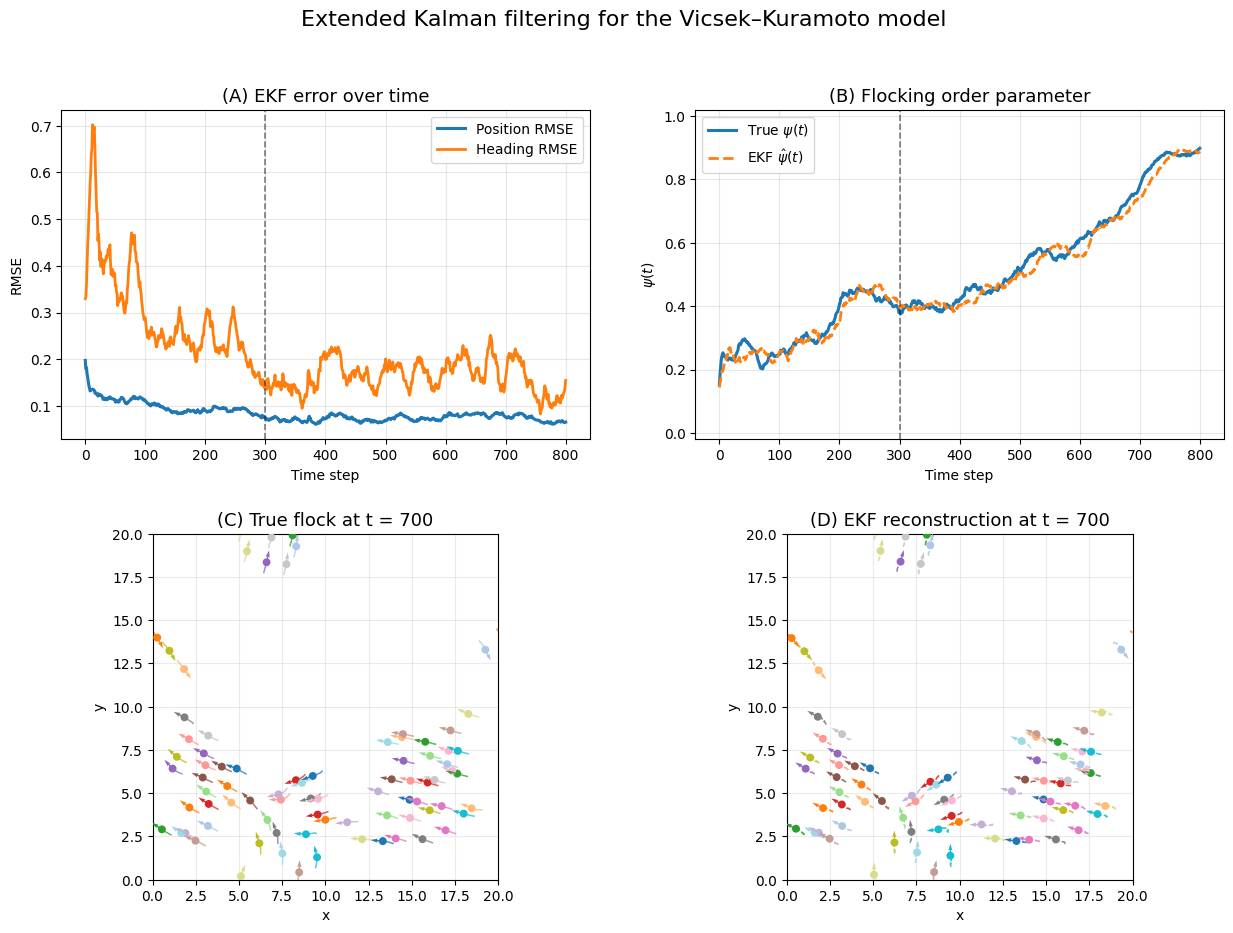

In [ ]:
diagnositcs = compute_rmse_diagnostics(states, filt_means)

build_dissertation_figure(
    pos=pos,
    theta=theta,
    filt_means=filt_means,
    diagnostics=diagnostics,
    L=p.L,
    burn_in=300,
    snapshot_t=700,     
    trail_len=35,
    arrow_scale=0.7,
    figsize=(15, 10),
    save_path="vk_ekf_dissertation_figure.png"
)

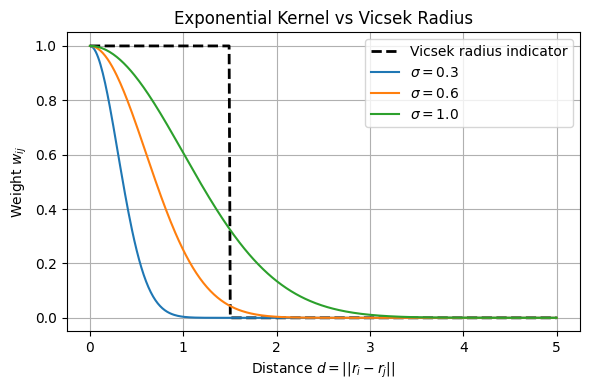

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# distance values
d = np.linspace(0, 5, 400)

# Vicsek interaction radius
R = 1.5
indicator = (d <= R).astype(float)

# kernel widths
sigma_values = [0.3, 0.6, 1.0]

plt.figure(figsize=(6,4))

# plot indicator function
plt.plot(d, indicator, '--', color='black', linewidth=2,
         label="Vicsek radius indicator")

# plot exponential kernels
for sigma in sigma_values:
    w = np.exp(-(d**2)/(2*sigma**2))
    plt.plot(d, w, label=f"$\\sigma={sigma}$")

plt.xlabel("Distance $d = ||r_i - r_j||$")
plt.ylabel("Weight $w_{ij}$")
plt.title("Exponential Kernel vs Vicsek Radius")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("exponential_kernel_overlay.png", dpi=300)
plt.show()

In [ ]:
def baseline_observation_only(observations, L, dt=1.0):
    """
    Observation-only baseline.

    Uses the observed positions directly and estimates headings from the
    displacement between consecutive observations.

    Parameters:
    observations : array, shape (T+1, 2N)
        Noisy position observations.
    L : float
        Periodic box size.
    dt : float
        Time step. Included for consistency, though headings are determined
        from direction of motion rather than speed.

    Returns:
    baseline_means : array, shape (T+1, 3N)
        State estimates in packed form [x1, y1, th1, x2, y2, th2, ...].
    """
    T_plus_1, obs_dim = observations.shape
    N = obs_dim // 2

    baseline_means = np.zeros((T_plus_1, 3 * N))

    # Extract observed positions
    x_obs = observations[:, 0::2]
    y_obs = observations[:, 1::2]

    # Fill positions directly from the observations
    baseline_means[:, 0::3] = x_obs
    baseline_means[:, 1::3] = y_obs

    # Estimate headings from observed motion
    # At time t, use the displacement from t-1 to t.
    theta_est = np.zeros((T_plus_1, N))

    for t in range(1, T_plus_1):
        dx = periodic_error(x_obs[t], x_obs[t - 1], L)
        dy = periodic_error(y_obs[t], y_obs[t - 1], L)
        theta_est[t] = wrap_angle(np.arctan2(dy, dx))

    # For t = 0 there is no previous displacement, so copy the first available estimate
    if T_plus_1 > 1:
        theta_est[0] = theta_est[1]
    else:
        theta_est[0] = 0.0

    baseline_means[:, 2::3] = theta_est

    return baseline_means


def compute_rmse_diagnostics_periodic(states, filt_means, L):
    """
    Compute RMSE diagnostics over time, respecting periodic positions and wrapped angles.

    Parameters:
    states : array, shape (T+1, 3N)
        True latent states.
    filt_means : array, shape (T+1, 3N)
        Estimated states.
    L : float
        Periodic box size.

    Returns:
    diagnostics : dict
        Time series and summary RMSE values for x, y, position, and heading.
    """
    T_plus_1, state_dim = states.shape
    N = state_dim // 3

    x_rmse_t = np.zeros(T_plus_1)
    y_rmse_t = np.zeros(T_plus_1)
    pos_rmse_t = np.zeros(T_plus_1)
    heading_rmse_t = np.zeros(T_plus_1)

    for t in range(T_plus_1):
        x_true = states[t, 0::3]
        y_true = states[t, 1::3]
        th_true = states[t, 2::3]

        x_est = filt_means[t, 0::3]
        y_est = filt_means[t, 1::3]
        th_est = filt_means[t, 2::3]

        x_err = periodic_error(x_est, x_true, L)
        y_err = periodic_error(y_est, y_true, L)
        th_err = angle_diff(th_est, th_true)

        x_rmse_t[t] = np.sqrt(np.mean(x_err**2))
        y_rmse_t[t] = np.sqrt(np.mean(y_err**2))
        pos_rmse_t[t] = np.sqrt(np.mean(x_err**2 + y_err**2))
        heading_rmse_t[t] = np.sqrt(np.mean(th_err**2))

    diagnostics = {
        "x_rmse_t": x_rmse_t,
        "y_rmse_t": y_rmse_t,
        "pos_rmse_t": pos_rmse_t,
        "heading_rmse_t": heading_rmse_t,
        "mean_x_rmse": np.mean(x_rmse_t),
        "mean_y_rmse": np.mean(y_rmse_t),
        "mean_pos_rmse": np.mean(pos_rmse_t),
        "mean_heading_rmse": np.mean(heading_rmse_t),
        "final_x_rmse": x_rmse_t[-1],
        "final_y_rmse": y_rmse_t[-1],
        "final_pos_rmse": pos_rmse_t[-1],
        "final_heading_rmse": heading_rmse_t[-1],
    }

    return diagnostics

In [34]:
def run_prediction_only_baseline(pos, theta, params, seed=123):
    """
    Prediction-only baseline:
    start from the same initial guess as EKF, then propagate using
    vk_state_transition without measurement updates.
    """
    T_plus_1, N, _ = pos.shape
    rng = np.random.default_rng(seed + 1)

    pos0_est = wrap_box(pos[0] + 0.15 * rng.standard_normal(size=(N, 2)), params.L)
    theta0_est = wrap_angle(theta[0] + 0.35 * rng.standard_normal(size=N))
    m0 = pack_state(pos0_est, theta0_est)

    pred_means = np.zeros((T_plus_1, 3 * N))
    pred_means[0] = m0

    for t in range(T_plus_1 - 1):
        pred_means[t + 1] = vk_state_transition(pred_means[t], params)

    return pred_means

In [33]:
def compare_filters_with_baselines(pos, theta, observations, filt_means, params, burn_in=0, seed=123):
    """
    Compare EKF against:
      - observation-only baseline
      - prediction-only baseline
    """
    states = build_states_from_sim(pos, theta)

    obs_only_means = baseline_observation_only(observations, L=params.L, dt=params.dt)
    pred_only_means = run_prediction_only_baseline(pos, theta, params, seed=seed)

    # optionally ignore transient
    states_eval = states[burn_in:]
    ekf_eval = filt_means[burn_in:]
    obs_eval = obs_only_means[burn_in:]
    pred_eval = pred_only_means[burn_in:]

    ekf_diag = compute_rmse_diagnostics_periodic(states_eval, ekf_eval, L=params.L)
    obs_diag = compute_rmse_diagnostics_periodic(states_eval, obs_eval, L=params.L)
    pred_diag = compute_rmse_diagnostics_periodic(states_eval, pred_eval, L=params.L)

    table = pd.DataFrame({
        "Method": ["Observation only", "Prediction only", "EKF"],
        "Position RMSE": [
            obs_diag["mean_pos_rmse"],
            pred_diag["mean_pos_rmse"],
            ekf_diag["mean_pos_rmse"],
        ],
        "Heading RMSE": [
            obs_diag["mean_heading_rmse"],
            pred_diag["mean_heading_rmse"],
            ekf_diag["mean_heading_rmse"],
        ],
        "Final position RMSE": [
            obs_diag["final_pos_rmse"],
            pred_diag["final_pos_rmse"],
            ekf_diag["final_pos_rmse"],
        ],
        "Final heading RMSE": [
            obs_diag["final_heading_rmse"],
            pred_diag["final_heading_rmse"],
            ekf_diag["final_heading_rmse"],
        ],
    })

    return table, {"EKF": ekf_diag, "Observation only": obs_diag, "Prediction only": pred_diag}

In [31]:
def plot_method_comparison(diag_dict):
    """
    Plot position and heading RMSE over time for multiple methods.
    """
    methods = list(diag_dict.keys())
    T_plus_1 = len(next(iter(diag_dict.values()))["pos_rmse_t"])
    t = np.arange(T_plus_1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for method in methods:
        axes[0].plot(t, diag_dict[method]["pos_rmse_t"], label=method)
        axes[1].plot(t, diag_dict[method]["heading_rmse_t"], label=method)

    axes[0].set_title("Position RMSE over time")
    axes[0].set_ylabel("Position RMSE")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Heading RMSE over time")
    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel("Heading RMSE")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

             Method  Position RMSE  Heading RMSE  Final position RMSE  \
0  Observation only          0.423         1.784                0.416   
1   Prediction only          5.461         1.080                5.685   
2               EKF          0.073         0.164                0.065   

   Final heading RMSE  
0               1.713  
1               0.857  
2               0.155  


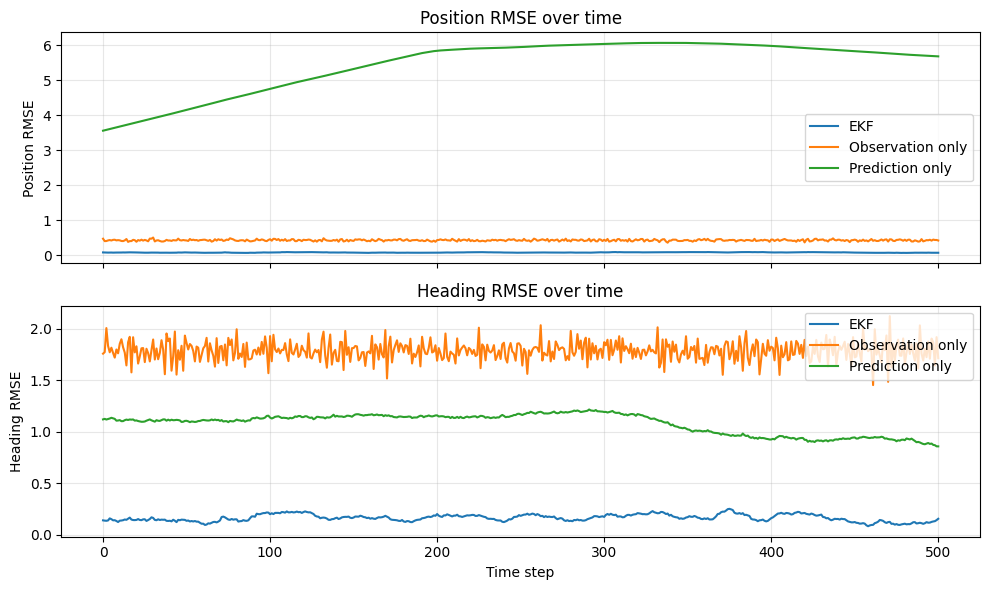

In [38]:
comparison_table, diag_dict = compare_filters_with_baselines(
    pos=pos,
    theta=theta,
    observations=observations,
    filt_means=filt_means,
    params=p,
    burn_in=300,
    seed=123
)

print(comparison_table.round(3))
plot_method_comparison(diag_dict)